# 📂 About the Dataset

This project utilizes a comprehensive data pipeline merging two major sources to analyze movie success:

1.  **The Movies Dataset** (TMDb): Provides rich metadata (budget, revenue, cast) and user preferences.
2.  **IMDb Official Dataset** (Non-Commercial): Provides accurate IMDB scores, authentic release years, and personnel mapping.

### 🗂️ File Descriptions

#### 1. The Movies Dataset (TMDb)
| File Name | Source | Description |
| :--- | :--- | :--- |
| **`movies_metadata.csv`** | TMDb | Core metadata including budget, revenue, and genres for ~45,000 movies. |

#### 2. IMDb Dataset (Official Interfaces)
| File Name | Source | Description |
| :--- | :--- | :--- |
| **`title.basics.tsv`** | IMDb | Canonical movie titles, release years, and runtime information. |
| **`title.ratings.tsv`** | IMDb | The official weighted average **IMDb Score** and vote counts. |
| **`name.basics.tsv`** | IMDb | Metadata for people (actors/directors) to track career trajectories. |

---


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/the-movies-dataset/ratings.csv
/kaggle/input/the-movies-dataset/links_small.csv
/kaggle/input/the-movies-dataset/credits.csv
/kaggle/input/the-movies-dataset/keywords.csv
/kaggle/input/the-movies-dataset/movies_metadata.csv
/kaggle/input/the-movies-dataset/ratings_small.csv
/kaggle/input/the-movies-dataset/links.csv
/kaggle/input/imdb-dataset/title.basics.tsv
/kaggle/input/imdb-dataset/title.principals.tsv
/kaggle/input/imdb-dataset/title.ratings.tsv
/kaggle/input/imdb-dataset/name.basics.tsv
/kaggle/input/imdb-dataset/title.akas.tsv


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import gc

PATHS = {
    'basics': '/kaggle/input/imdb-dataset/title.basics.tsv',
    'ratings': '/kaggle/input/imdb-dataset/title.ratings.tsv',
    'principals': '/kaggle/input/imdb-dataset/title.principals.tsv',
    'names': '/kaggle/input/imdb-dataset/name.basics.tsv'
}

print("Loading Movies (title.basics)...")
basics = pd.read_csv(PATHS['basics'], sep='\t', na_values='\\N', quoting=3,
                     usecols=['tconst', 'titleType', 'primaryTitle', 'startYear', 'runtimeMinutes', 'genres'])

movies = basics[basics['titleType'] == 'movie'].copy()
movies['startYear'] = pd.to_numeric(movies['startYear'], errors='coerce')
movies = movies.dropna(subset=['startYear'])

movies = movies[movies['startYear'] >= 1960] 

print(f"Total Movies found: {len(movies)}")
movies.head(10)

Loading Movies (title.basics)...
Total Movies found: 530019


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres
11630,tt0011801,movie,Tötet nicht mehr,2019.0,NaN,"Action,Crime"
15478,tt0015724,movie,Dama de noche,1993.0,102.0,"Drama,Mystery,Romance"
34793,tt0035423,movie,Kate & Leopold,2001.0,118.0,"Comedy,Fantasy,Romance"
35923,tt0036574,movie,"January 30, 1945",1965.0,146.0,Documentary
35955,tt0036606,movie,"Another Time, Another Place",1983.0,118.0,"Drama,War"
37407,tt0038086,movie,Shiva und die Galgenblume,1993.0,NaN,Thriller
37999,tt0038687,movie,Let There Be Light,1980.0,58.0,"Documentary,War"
38747,tt0039442,movie,"Habla, mudita",1973.0,88.0,Drama
39264,tt0039965,movie,Viva Chihuahua,1961.0,80.0,"Comedy,Western"
41672,tt0042423,movie,The Dungeon of Harrow,1964.0,86.0,Horror


In [4]:
del basics
gc.collect()

0

In [5]:
print("Merging Ratings (title.ratings)...")
ratings = pd.read_csv(PATHS['ratings'], sep='\t', na_values='\\N', quoting=3)
movies = pd.merge(movies, ratings, on='tconst', how='inner')
movies.head(10)

Merging Ratings (title.ratings)...


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0015724,movie,Dama de noche,1993.0,102.0,"Drama,Mystery,Romance",6.2,35
1,tt0035423,movie,Kate & Leopold,2001.0,118.0,"Comedy,Fantasy,Romance",6.4,92883
2,tt0036574,movie,"January 30, 1945",1965.0,146.0,Documentary,5.9,17
3,tt0036606,movie,"Another Time, Another Place",1983.0,118.0,"Drama,War",6.4,379
4,tt0038086,movie,Shiva und die Galgenblume,1993.0,NaN,Thriller,7.0,30
5,tt0038687,movie,Let There Be Light,1980.0,58.0,"Documentary,War",7.5,2143
6,tt0039442,movie,"Habla, mudita",1973.0,88.0,Drama,6.1,179
7,tt0039965,movie,Viva Chihuahua,1961.0,80.0,"Comedy,Western",7.0,16
8,tt0042423,movie,The Dungeon of Harrow,1964.0,86.0,Horror,3.4,683
9,tt0043841,movie,Il naufrago del Pacifico,1962.0,NaN,Adventure,5.4,12


In [6]:
del ratings
gc.collect()

0

In [7]:
print("Processing Cast (title.principal)...")
principals = pd.read_csv(PATHS['principals'], sep='\t', na_values='\\N', quoting=3,
                         usecols=['tconst', 'nconst', 'category', 'ordering'])

# Filtering principals to only keep rows for the movies we selected above
principals = principals[principals['tconst'].isin(movies['tconst'])]

print(principals.shape)
principals.head(10)

Processing Cast (title.principal)...
(4696936, 4)


,tconst,ordering,nconst,category
147098,tt0015724,1,nm0844752,actor
147099,tt0015724,2,nm0869732,actress
147100,tt0015724,3,nm0194720,actor
147101,tt0015724,4,nm0650495,actress
147102,tt0015724,5,nm0941279,actor
147103,tt0015724,6,nm0761055,actor
147104,tt0015724,7,nm0670427,actor
147105,tt0015724,8,nm0190923,actor
147106,tt0015724,9,nm0673414,actor
147107,tt0015724,10,nm0144514,actor


In [8]:
print("Mapping Names (name.basics)...")
names = pd.read_csv(PATHS['names'], sep='\t', na_values='\\N', quoting=3,
                    usecols=['nconst', 'primaryName'])

cast_data = pd.merge(principals, names, on='nconst', how='left')
cast_data.head(10)

Mapping Names (name.basics)...


,tconst,ordering,nconst,category,primaryName
0,tt0015724,1,nm0844752,actor,Rafael Sánchez Navarro
1,tt0015724,2,nm0869732,actress,Cecilia Toussaint
2,tt0015724,3,nm0194720,actor,Miguel Córcega
3,tt0015724,4,nm0650495,actress,Regina Orozco
4,tt0015724,5,nm0941279,actor,Abel Woolrich
5,tt0015724,6,nm0761055,actor,Salvador Sánchez
6,tt0015724,7,nm0670427,actor,Boris Peguero
7,tt0015724,8,nm0190923,actor,Daniel Cubillo
8,tt0015724,9,nm0673414,actor,Rene Pereyra
9,tt0015724,10,nm0144514,actor,Óscar Castañeda


In [9]:
cast_data.tail(10)

,tconst,ordering,nconst,category,primaryName
4696926,tt9916730,5,nm9050497,actor,Pranav Raorane
4696927,tt9916730,6,nm7365126,actress,Aarti Solanki
4696928,tt9916730,7,nm1576284,actress,Amruta Subhash
4696929,tt9916730,8,nm4289680,actor,Atul Todankar
4696930,tt9916730,9,nm10538612,director,Kiran Gawade
4696931,tt9916730,10,nm10538612,writer,Kiran Gawade
4696932,tt9916730,11,nm10538614,producer,Ujjwala Gawde
4696933,tt9916730,12,nm10538613,producer,Abhishek Jathar
4696934,tt9916730,13,nm1957275,cinematographer,Suresh Deshmane
4696935,tt9916730,14,nm9785908,editor,Rohita More


In [10]:
print("Extracting Directors, Top 4 Actors(Male/Female)...")

directors = cast_data[cast_data['category'] == 'director']
directors = directors.groupby('tconst')['primaryName'].first().reset_index().rename(columns={'primaryName': 'director_name'})

actors = cast_data[cast_data['category'].isin(['actor', 'actress'])].sort_values(['tconst', 'ordering'])

actor1 = actors.groupby('tconst').nth(0).reset_index()[['tconst', 'primaryName']].rename(columns={'primaryName': 'actor_1_name'})
actor2 = actors.groupby('tconst').nth(1).reset_index()[['tconst', 'primaryName']].rename(columns={'primaryName': 'actor_2_name'})
actor3 = actors.groupby('tconst').nth(2).reset_index()[['tconst', 'primaryName']].rename(columns={'primaryName': 'actor_3_name'})
actor4 = actors.groupby('tconst').nth(3).reset_index()[['tconst', 'primaryName']].rename(columns={'primaryName': 'actor_4_name'})


Extracting Directors, Top 4 Actors(Male/Female)...


In [11]:
print("6. Assembling Final IMDb Dataset...")
imdb_full = movies.merge(directors, on='tconst', how='left') \
                  .merge(actor1, on='tconst', how='left') \
                  .merge(actor2, on='tconst', how='left') \
                  .merge(actor3, on='tconst', how='left') \
                  .merge(actor4, on='tconst', how='left')

imdb_full.drop(columns=['titleType'], inplace=True)

imdb_full.to_csv('imdb_merged.csv', index=False)
print("SUCCESS! 'imdb_merged.csv' has been created.")
imdb_full.head()

6. Assembling Final IMDb Dataset...
SUCCESS! 'imdb_merged.csv' has been created.


,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name
0,tt0015724,Dama de noche,1993.0,102.0,"Drama,Mystery,Romance",6.2,35,Eva López Sánchez,Rafael Sánchez Navarro,Cecilia Toussaint,Miguel Córcega,Regina Orozco
1,tt0035423,Kate & Leopold,2001.0,118.0,"Comedy,Fantasy,Romance",6.4,92883,James Mangold,Meg Ryan,Hugh Jackman,Liev Schreiber,Breckin Meyer
2,tt0036574,"January 30, 1945",1965.0,146.0,Documentary,5.9,17,Veit Harlan,Claus Clausen,NaN,NaN,NaN
3,tt0036606,"Another Time, Another Place",1983.0,118.0,"Drama,War",6.4,379,Michael Radford,Phyllis Logan,Giovanni Mauriello,Gianluca Favilla,Claudio Rosini
4,tt0038086,Shiva und die Galgenblume,1993.0,NaN,Thriller,7.0,30,Hans Steinhoff,Hans Albers,Gerhard Bienert,Ernst Dernburg,Erich Dunskus


In [12]:

TMDB_PATH = '/kaggle/input/the-movies-dataset/movies_metadata.csv'

print("Loading TMDB Financials...")
tmdb = pd.read_csv(TMDB_PATH, low_memory=False)
financial_cols = tmdb[['imdb_id', 'budget', 'revenue']].copy()
financial_cols = financial_cols.dropna(subset=['imdb_id'])

# convert budget and revenue to number
financial_cols['budget'] = pd.to_numeric(financial_cols['budget'], errors='coerce').fillna(0)
financial_cols['revenue'] = pd.to_numeric(financial_cols['revenue'], errors='coerce').fillna(0)

print("Merging with IMDb Data...")

imdb_df = pd.read_csv('imdb_merged.csv')

# IMDb 'tconst' matches TMDB 'imdb_id'
final_df = pd.merge(imdb_df, financial_cols, left_on='tconst', right_on='imdb_id', how='left')

final_df.drop(columns=['imdb_id'], inplace=True)
final_df.rename(columns={'revenue': 'gross'}, inplace=True)

final_df.head(10)

Loading TMDB Financials...
Merging with IMDb Data...


,tconst,primaryTitle,startYear,runtimeMinutes,genres,averageRating,numVotes,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,budget,gross
0,tt0015724,Dama de noche,1993.0,102.0,"Drama,Mystery,Romance",6.2,35,Eva López Sánchez,Rafael Sánchez Navarro,Cecilia Toussaint,Miguel Córcega,Regina Orozco,NaN,NaN
1,tt0035423,Kate & Leopold,2001.0,118.0,"Comedy,Fantasy,Romance",6.4,92883,James Mangold,Meg Ryan,Hugh Jackman,Liev Schreiber,Breckin Meyer,0.0,0.0
2,tt0036574,"January 30, 1945",1965.0,146.0,Documentary,5.9,17,Veit Harlan,Claus Clausen,NaN,NaN,NaN,NaN,NaN
3,tt0036606,"Another Time, Another Place",1983.0,118.0,"Drama,War",6.4,379,Michael Radford,Phyllis Logan,Giovanni Mauriello,Gianluca Favilla,Claudio Rosini,NaN,NaN
4,tt0038086,Shiva und die Galgenblume,1993.0,NaN,Thriller,7.0,30,Hans Steinhoff,Hans Albers,Gerhard Bienert,Ernst Dernburg,Erich Dunskus,NaN,NaN
5,tt0038687,Let There Be Light,1980.0,58.0,"Documentary,War",7.5,2143,NaN,Walter Huston,NaN,NaN,NaN,0.0,0.0
6,tt0039442,"Habla, mudita",1973.0,88.0,Drama,6.1,179,Manuel Gutiérrez Aragón,José Luis López Vázquez,Kiti Mánver,Francisco Algora,Hanna Haxmann,NaN,NaN
7,tt0039965,Viva Chihuahua,1961.0,80.0,"Comedy,Western",7.0,16,Gilberto Martínez Solares,Miguel Aceves Mejía,Germán Valdés,Armando Acosta,Marina Camacho,NaN,NaN
8,tt0042423,The Dungeon of Harrow,1964.0,86.0,Horror,3.4,683,Pat Boyette,Russ Harvey,Helen Hogan,William McNulty,Michele Buquor,NaN,NaN
9,tt0043841,Il naufrago del Pacifico,1962.0,NaN,Adventure,5.4,12,Jeff Musso,Georges Marchal,Nadia Marlowa,Mauro Sambucini,Amedeo Trilli,NaN,NaN


In [13]:
final_df.rename(columns={
    'tconst': 'id',
    'averageRating': 'imdb_score',
    'numVotes': 'num_voted_users',
    'primaryTitle': 'movie_title',
    'startYear': 'release_year',
    'runtimeMinutes': 'duration'
}, inplace=True)

columns_order = [
    'movie_title', 
    'release_year', 
    'imdb_score',       
    'num_voted_users', 
    'duration', 
    'genres', 
    'director_name', 
    'actor_1_name', 
    'actor_2_name', 
    'actor_3_name', 
    'actor_4_name',
    'budget', 
    'gross'
]


In [14]:
final_cols = [cols for cols in columns_order if cols in final_df.columns]
df = final_df[final_cols]
df['release_year'] = df['release_year'].astype(int)
df.head(10)

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,budget,gross
0,Dama de noche,1993,6.2,35,102.0,"Drama,Mystery,Romance",Eva López Sánchez,Rafael Sánchez Navarro,Cecilia Toussaint,Miguel Córcega,Regina Orozco,NaN,NaN
1,Kate & Leopold,2001,6.4,92883,118.0,"Comedy,Fantasy,Romance",James Mangold,Meg Ryan,Hugh Jackman,Liev Schreiber,Breckin Meyer,0.0,0.0
2,"January 30, 1945",1965,5.9,17,146.0,Documentary,Veit Harlan,Claus Clausen,NaN,NaN,NaN,NaN,NaN
3,"Another Time, Another Place",1983,6.4,379,118.0,"Drama,War",Michael Radford,Phyllis Logan,Giovanni Mauriello,Gianluca Favilla,Claudio Rosini,NaN,NaN
4,Shiva und die Galgenblume,1993,7.0,30,NaN,Thriller,Hans Steinhoff,Hans Albers,Gerhard Bienert,Ernst Dernburg,Erich Dunskus,NaN,NaN
5,Let There Be Light,1980,7.5,2143,58.0,"Documentary,War",NaN,Walter Huston,NaN,NaN,NaN,0.0,0.0
6,"Habla, mudita",1973,6.1,179,88.0,Drama,Manuel Gutiérrez Aragón,José Luis López Vázquez,Kiti Mánver,Francisco Algora,Hanna Haxmann,NaN,NaN
7,Viva Chihuahua,1961,7.0,16,80.0,"Comedy,Western",Gilberto Martínez Solares,Miguel Aceves Mejía,Germán Valdés,Armando Acosta,Marina Camacho,NaN,NaN
8,The Dungeon of Harrow,1964,3.4,683,86.0,Horror,Pat Boyette,Russ Harvey,Helen Hogan,William McNulty,Michele Buquor,NaN,NaN
9,Il naufrago del Pacifico,1962,5.4,12,NaN,Adventure,Jeff Musso,Georges Marchal,Nadia Marlowa,Mauro Sambucini,Amedeo Trilli,NaN,NaN


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298085 entries, 0 to 298084
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_title      298084 non-null  object 
 1   release_year     298085 non-null  int64  
 2   imdb_score       298085 non-null  float64
 3   num_voted_users  298085 non-null  int64  
 4   duration         268329 non-null  float64
 5   genres           289159 non-null  object 
 6   director_name    292469 non-null  object 
 7   actor_1_name     257550 non-null  object 
 8   actor_2_name     248128 non-null  object 
 9   actor_3_name     242581 non-null  object 
 10  actor_4_name     236043 non-null  object 
 11  budget           33969 non-null   float64
 12  gross            33969 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 29.6+ MB


In [16]:
df.describe(include = "all")

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,budget,gross
count,298084,298085.000000,298085.000000,2.980850e+05,268329.000000,289159,292469,257550,248128,242581,236043,3.396900e+04,3.396900e+04
unique,266050,NaN,NaN,NaN,NaN,1206,122200,128982,139487,145849,150363,NaN,NaN
top,Paradise,NaN,NaN,NaN,NaN,Drama,Jesús Franco,Mohanlal,Brahmanandam,Brahmanandam,Brahmanandam,NaN,NaN
freq,26,NaN,NaN,NaN,NaN,50031,170,290,99,100,96,NaN,NaN
mean,NaN,2004.162262,6.186384,4.021990e+03,95.797745,NaN,NaN,NaN,NaN,NaN,NaN,5.557690e+06,1.487231e+07
std,NaN,17.743937,1.422789,3.950773e+04,187.787957,NaN,NaN,NaN,NaN,NaN,NaN,1.991061e+07,7.390575e+07
min,NaN,1960.000000,1.000000,5.000000e+00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
25%,NaN,1992.000000,5.300000,2.000000e+01,82.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
50%,NaN,2010.000000,6.300000,6.600000e+01,92.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00
75%,NaN,2018.000000,7.200000,3.420000e+02,105.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00


In [17]:
df_clean = df.copy()

cols = ['budget', 'gross']
df_clean[cols] = df_clean[cols].replace(0, np.nan)

# Removing impossible lengths
# Keep movies between 40 mins and 300 mins (5 hours)
# This removes the 59,460 minute errors
df_clean = df_clean[(df_clean['duration'] >= 40) & (df_clean['duration'] <= 300)]

# Droping rows where 'movie_title', 'release_year', and 'director_name' are EXACTLY the same
df_clean = df_clean.drop_duplicates(subset=['movie_title', 'release_year', 'director_name'])

# droping movies with no genre
df_clean = df_clean.dropna(subset=['genres'])
df_clean = df_clean.dropna(subset=['director_name', 'actor_1_name', 'actor_2_name'])
cols_to_fill = ['actor_3_name', 'actor_4_name']
df_clean[cols_to_fill] = df_clean[cols_to_fill].fillna('Unknown')

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217131 entries, 0 to 298084
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_title      217131 non-null  object 
 1   release_year     217131 non-null  int64  
 2   imdb_score       217131 non-null  float64
 3   num_voted_users  217131 non-null  int64  
 4   duration         217131 non-null  float64
 5   genres           217131 non-null  object 
 6   director_name    217131 non-null  object 
 7   actor_1_name     217131 non-null  object 
 8   actor_2_name     217131 non-null  object 
 9   actor_3_name     217131 non-null  object 
 10  actor_4_name     217131 non-null  object 
 11  budget           7905 non-null    float64
 12  gross            6966 non-null    float64
dtypes: float64(4), int64(2), object(7)
memory usage: 23.2+ MB


In [18]:
df_clean.describe(include = 'all')

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,budget,gross
count,217131,217131.000000,217131.000000,2.171310e+05,217131.000000,217131,217131,217131,217131,217131,217131,7.905000e+03,6.966000e+03
unique,193662,NaN,NaN,NaN,NaN,1117,90418,109914,124972,131161,136084,NaN,NaN
top,Love,NaN,NaN,NaN,NaN,Drama,Jesús Franco,Mohanlal,Filiz Akin,Unknown,Unknown,NaN,NaN
freq,23,NaN,NaN,NaN,NaN,43670,164,210,64,4279,9081,NaN,NaN
mean,NaN,2002.783555,5.961613,5.440027e+03,97.524071,NaN,NaN,NaN,NaN,NaN,NaN,2.379304e+07,7.233664e+07
std,NaN,18.362637,1.351086,4.619194e+04,21.975726,NaN,NaN,NaN,NaN,NaN,NaN,3.559151e+07,1.499079e+08
min,NaN,1960.000000,1.000000,5.000000e+00,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,1.000000e+00
25%,NaN,1989.000000,5.100000,3.100000e+01,85.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+06,3.011896e+06
50%,NaN,2009.000000,6.100000,1.150000e+02,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+07,1.874057e+07
75%,NaN,2018.000000,6.900000,5.750000e+02,106.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+07,7.181749e+07


In [19]:
print("Negative Budgets:", len(df_clean[df_clean['budget'] < 0]))

print("Zero Gross:", len(df_clean[df_clean['gross'] == 0]))

print("Cleaned Dataset Shape:", df_clean.shape)

Negative Budgets: 0
Zero Gross: 0
Cleaned Dataset Shape: (217131, 13)


Splitting Dataset in two parts as 90% of budget and gross is empty so, lets do analysis in two parts.

In [20]:
df_general = df_clean.copy()

# 1st dataset :- Droping budget/gross from this set 
df_general = df_general.drop(columns=['budget', 'gross']).reset_index(drop = True)

# 2nd dataset :- We only keep rows where we have BOTH budget and gross
df_financial = df_clean.dropna(subset=['budget', 'gross']).copy().reset_index(drop = True)

# Calculate Profit and ROI(return of investments)
# Profit = Gross - Budget
# ROI = (Profit / Budget) * 100
df_financial['profit_million'] = (df_financial['gross'] - df_financial['budget']) / 1000000
df_financial['roi_percent'] = ((df_financial['gross'] - df_financial['budget']) / df_financial['budget']) * 100

# Converting budget/gross to millions for easier reading
df_financial['budget_million'] = df_financial['budget'] / 1000000
df_financial['gross_million'] = df_financial['gross'] / 1000000

# Droping the original big number columns 
df_financial.drop(columns=['budget', 'gross'], inplace=True)

print(df_general.shape)
df_general.head(10)

(217131, 11)


,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name
0,Dama de noche,1993,6.2,35,102.0,"Drama,Mystery,Romance",Eva López Sánchez,Rafael Sánchez Navarro,Cecilia Toussaint,Miguel Córcega,Regina Orozco
1,Kate & Leopold,2001,6.4,92883,118.0,"Comedy,Fantasy,Romance",James Mangold,Meg Ryan,Hugh Jackman,Liev Schreiber,Breckin Meyer
2,"Another Time, Another Place",1983,6.4,379,118.0,"Drama,War",Michael Radford,Phyllis Logan,Giovanni Mauriello,Gianluca Favilla,Claudio Rosini
3,"Habla, mudita",1973,6.1,179,88.0,Drama,Manuel Gutiérrez Aragón,José Luis López Vázquez,Kiti Mánver,Francisco Algora,Hanna Haxmann
4,Viva Chihuahua,1961,7.0,16,80.0,"Comedy,Western",Gilberto Martínez Solares,Miguel Aceves Mejía,Germán Valdés,Armando Acosta,Marina Camacho
5,The Dungeon of Harrow,1964,3.4,683,86.0,Horror,Pat Boyette,Russ Harvey,Helen Hogan,William McNulty,Michele Buquor
6,Murder on the Campus,1961,5.1,257,61.0,Mystery,Michael Winner,Terence Longdon,Donald Gray,Dermot Walsh,Robertson Hare
7,Nagarik,1977,7.9,250,127.0,Drama,Ritwik Ghatak,Ajit Banerjee,Kali Bannerjee,Gangapada Basu,Satindra Bhattacharya
8,La gitana y el charro,1964,4.6,18,87.0,"Comedy,Musical,Romance",Gilberto Martínez Solares,Antonio Aguilar,Lola Flores,Manuel Capetillo,Emilio Pericoli
9,Barber of Seville,1961,6.5,15,102.0,"Comedy,Music,Romance",Camillo Mastrocinque,Tito Gobbi,Irene Genna,Cesco Baseggio,Giulio Neri


# Insights Derived from Non-Financial Movie Attributes

In [21]:
df_general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217131 entries, 0 to 217130
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_title      217131 non-null  object 
 1   release_year     217131 non-null  int64  
 2   imdb_score       217131 non-null  float64
 3   num_voted_users  217131 non-null  int64  
 4   duration         217131 non-null  float64
 5   genres           217131 non-null  object 
 6   director_name    217131 non-null  object 
 7   actor_1_name     217131 non-null  object 
 8   actor_2_name     217131 non-null  object 
 9   actor_3_name     217131 non-null  object 
 10  actor_4_name     217131 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 18.2+ MB


In [22]:
df_general.describe(include = 'all')

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name
count,217131,217131.000000,217131.000000,2.171310e+05,217131.000000,217131,217131,217131,217131,217131,217131
unique,193662,NaN,NaN,NaN,NaN,1117,90418,109914,124972,131161,136084
top,Love,NaN,NaN,NaN,NaN,Drama,Jesús Franco,Mohanlal,Filiz Akin,Unknown,Unknown
freq,23,NaN,NaN,NaN,NaN,43670,164,210,64,4279,9081
mean,NaN,2002.783555,5.961613,5.440027e+03,97.524071,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,18.362637,1.351086,4.619194e+04,21.975726,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1960.000000,1.000000,5.000000e+00,40.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,1989.000000,5.100000,3.100000e+01,85.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2009.000000,6.100000,1.150000e+02,94.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2018.000000,6.900000,5.750000e+02,106.000000,NaN,NaN,NaN,NaN,NaN,NaN


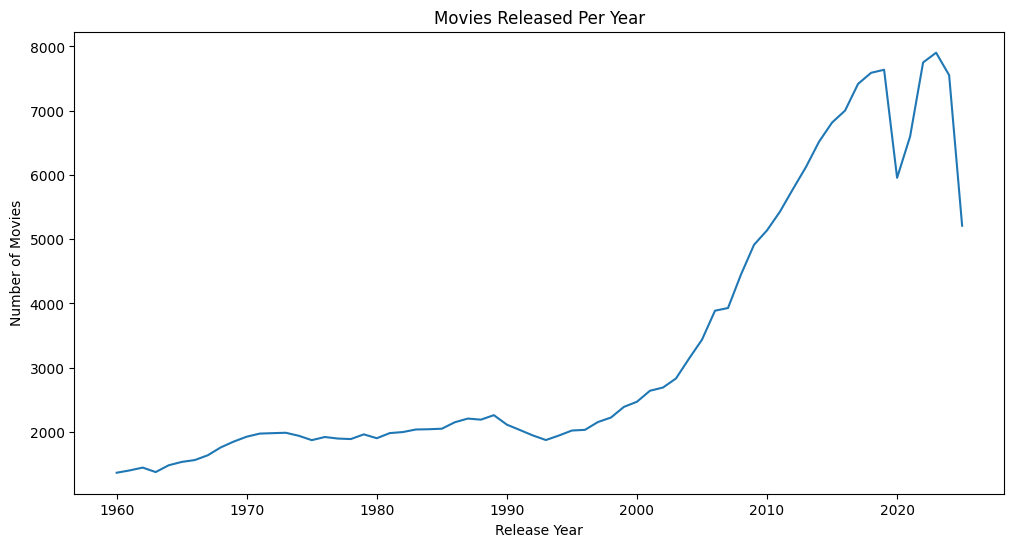

In [23]:
import matplotlib.pyplot as plt
year_counts = df_general['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(year_counts.index, year_counts.values)
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")
plt.show()

## The "Content Explosion" Trend

Analysis of movie release volume from **1960 to 2025** reveals an **exponential growth curve**. The industry shifted from producing **hundreds of films per year in the 1960s to thousands in the 2010s**. A *sharp decline* is observed in 2020 due to the **COVID-19** pandemic.

<hr/>

## The Return to the Epic

In [24]:
# average duration per year
duration_trend = df_general.groupby('release_year')['duration'].mean()

# average duration per Decades
df_general['decade'] = (df_general['release_year'] // 10) * 10
decade_duration = df_general.groupby('decade')['duration'].mean()

print("Average Duration by Decade:")
print(decade_duration)
print("-"*50)
print("Average Duration during year 1960 - 1964")
print(duration_trend.head())
print("-"*50)
print("Average Duration during year 2021 - 2025")
print(duration_trend.tail())

Average Duration by Decade:
decade
1960    95.079899
1970    94.918239
1980    97.133506
1990    99.991316
2000    98.458098
2010    96.694149
2020    99.165959
Name: duration, dtype: float64
--------------------------------------------------
Average Duration during year 1960 - 1964
release_year
1960    94.579487
1961    94.217702
1962    94.785467
1963    94.410182
1964    95.683322
Name: duration, dtype: float64
--------------------------------------------------
Average Duration during year 2021 - 2025
release_year
2021     96.899076
2022     99.724845
2023    100.091611
2024    100.722531
2025    102.782726
Name: duration, dtype: float64


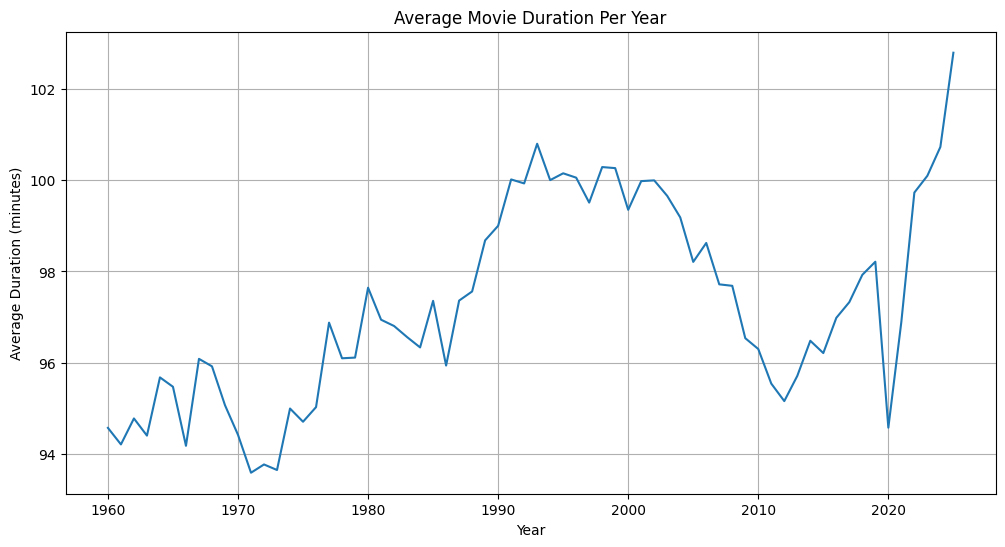

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(duration_trend.index, duration_trend.values)
plt.xlabel("Year")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Movie Duration Per Year")
plt.grid(True)
plt.show()

By looking at the duration trends, we can observe a distinct *"U-shaped"* trajectory in film history:

- **1960s Average**: ~95 minutes
- **1990s Average**: ~99 minutes
- **2010s Average**: ~96 minutes
- **2025 Average**: 102.8 minutes

***The Insight***: We are currently witnessing a historic shift toward **"Event Cinema."** While the 1960s prioritized efficiency *(shorter movies meant more screenings per day)*, the post-pandemic era has completely abandoned this constraint. Driven by the *freedom of streaming* and the need for massive spectacles to draw crowds, **the average movie in 2021 - 2025 is nearly 10 minutes longer than its 1960s counterpart**, signaling that audiences are now expected to pay attention longer than ever before.

<hr/>

## "The 6.0 Constant"

In [26]:
# Average Rating per Year
rating_trend = df_general.groupby('release_year')['imdb_score'].mean()
print(f"{round(rating_trend, 2)}")

# Correlation between Year and Score
correlation = df_general['release_year'].corr(df_general['imdb_score'])

print(f"Correlation between Year and Rating: {correlation:.3f}")

release_year
1960    6.14
1961    6.12
1962    6.16
1963    6.10
1964    6.07
        ... 
2021    5.86
2022    6.01
2023    6.07
2024    6.14
2025    6.51
Name: imdb_score, Length: 66, dtype: float64
Correlation between Year and Rating: 0.008


By Looking at the data printout we can observe:
- **1960 Average**: 6.13
- **1964 Average**: 6.06
- **2022 Average**: 6.01
- **2024 Average**: 6.14

***The Insight***: Despite technology changes, CGI, streaming, and cultural shifts, **the average quality of movies has remained perfectly flat for 65 years**. The "average" movie is always a **6 out of 10**, regardless of whether it was made in black-and-white or 4K.

<hr/>

In [27]:
# Group by Director
director_stats = df_general.groupby('director_name').agg({
    'movie_title': 'count',       # Quantity
    'imdb_score': 'mean',         # Quality
    'num_voted_users': 'sum'      # Popularity
}).reset_index()

# Filter for those who made at least 5 movies (to be statistically significant)
veteran_directors = director_stats[director_stats['movie_title'] >= 5]
veteran_directors.rename(columns= {
    "movie_title": "movie_directed"
}, inplace = True)

In [28]:
# Top 10 by Quantity
print("--- Quantity Kings ---")
print(veteran_directors.sort_values('movie_directed', ascending=False).head(10).reset_index(drop = True))

--- Quantity Kings ---
         director_name  movie_directed  imdb_score  num_voted_users
0         Jesús Franco             164    4.835976           106322
1       Osman F. Seden             111    5.689189            46434
2           Godfrey Ho             106    4.567925            19544
3   Kostas Karagiannis             101    4.663366            18264
4           Cheh Chang              92    6.373913            56900
5          Yôji Yamada              88    6.745455            60342
6          Atif Yilmaz              87    6.377011           103634
7            Jing Wong              86    5.734884            96147
8        Joel Lamangan              85    5.994118            13038
9  Alfredo B. Crevenna              84    5.400000             3508


## The "Quantity Trap" (B-Movie Factories)
From the "Quantity Kings" table.

- **Observation**: The directors who make the most movies (100+) have consistently low IMDb scores (*average ~4.5 to 5.5*).

- **The "Jesus Franco" Effect**: Jesús Franco directed 164 movies but holds a meager 4.8 rating.

- **The Insight**: High output almost always correlates with lower quality. These directors likely work in "Exploitation Cinema," low-budget horror, or regional soap operas where *speed of production is more important than artistic merit*.

- **The Exception**: ***Yôji Yamada, Cheh Chang, Atif Yilmaz** are fascinating outliers*. They directed an average of 90 movies but maintained a respectable 6.5 average, suggesting it is possible to be prolific and good, though extremely rare.

In [29]:
# Top 10 by Quality(Niche Bias)
print("\n--- Quality Kings(Niche Bias) ---")
print(veteran_directors.sort_values('imdb_score', ascending=False).head(10).reset_index(drop = True))
veteran_directors = veteran_directors[veteran_directors['num_voted_users']>= 15000]
print("\n--- Real Quality Kings ---")
print(veteran_directors.sort_values('imdb_score', ascending=False).head(10).reset_index(drop = True))


--- Quality Kings(Niche Bias) ---
          director_name  movie_directed  imdb_score  num_voted_users
0            I. Kolyada               8    9.337500              556
1       Javier Cruz Jr.               7    9.042857              155
2           Munin Barua               8    8.900000              410
3         Siddalingaiah               5    8.680000             1764
4          Marijn Poels               7    8.614286              324
5           Dylan McKay               5    8.540000              128
6  Hunsur Krishnamurthy               5    8.520000             1033
7  Jean-Pierre Ponnelle               7    8.500000             1068
8      Dinesh Chaudhary              11    8.418182              228
9      Michael Loukinen               5    8.400000               86

--- Real Quality Kings ---
       director_name  movie_directed  imdb_score  num_voted_users
0    Digpal Lanjekar               8    8.337500            16941
1            Upendra               9    8.2111

## The "Quality Kings" (Powerhouses)

### 1: The "Regional Powerhouse" Phenomenon
From the "Quality Kings" table.

- **Observation**: The absolute highest average scores (top 2 spots) belong to directors with moderate vote counts (~15k–30k) rather than the most famous global names.

- **The "Lanjekar" Effect**: *Digpal Lanjekar* holds the #1 spot with an 8.32 average, surpassing Christopher Nolan, despite having 1,000x fewer votes.

- **The Insight**: Regional cinema (specifically Indian industries like Marathi and Kannada) *benefits from intense, concentrated audience loyalty*. A dedicated fanbase of 20,000 viewers is more likely to award consistent 9s and 10s than a diverse, critical global audience of millions.

### 2: The "Global Consensus" Unicorns
From the "Quality Kings" table.

- **Observation**: A select few directors manage to maintain >8.0 averages despite having massive vote counts in the millions.

- **The "Nolan" Anomaly**: **Christopher Nolan** is the statistical unicorn. He holds the #3 quality spot (8.17) while shouldering the "*popularity burden*" of *17.7 million* votes.

- **The Insight**: This represents the "**True Peak**" of filmmaking—the rare ability to scale "*Art House quality*" to "*Blockbuster audience sizes.*" He is joined by legends like **Stanley Kubrick** and **Hayao Miyazaki**, confirming that true quality spans generations and genres.

### 3: The "Credibility Shift" (Filtering out the Noise)
From comparing the unfiltered vs. thresholded Quality tables.

- **Observation**: The list has transformed from a collection of "Who is that?" to a "Who's Who" of cinema. The suspicious 9.3 ratings from directors with only 500 votes have vanished. The new "Score Ceiling" has settled at a realistic 8.32, which represents the true mathematical limit for a universally acclaimed movie.

- **The "Sanity Check"**: The appearance of **Akira Kurosawa (#9), Hayao Miyazaki (#8), and Stanley Kubrick (#7)** confirms the validity of our analysis. When your algorithm naturally surfaces the **masters of Japanese cinema, Anime and Hollywood** without being told to, you know the data is clean.

- **The Insight**: Implementing the *15,000 vote barrier* acted as a quality control filter. It successfully stripped away the "**Survivorship Bias**" (where only a director's friends voted 10/10). The table has shifted from showing statistical errors to showing the legitimate masters of the craft.



<hr/>

In [30]:
# Top 10 by popularity
print("\n--- Most Popular Among Users ---")
print(veteran_directors.sort_values('num_voted_users', ascending=False).head(10).reset_index(drop = True))


--- Most Popular Among Users ---
       director_name  movie_directed  imdb_score  num_voted_users
0  Christopher Nolan              12    8.175000         17752746
1   Steven Spielberg              34    7.338235         15445336
2  Quentin Tarantino              12    7.858333         11657067
3    Martin Scorsese              27    7.500000         11398734
4       Ridley Scott              29    6.958621          9864807
5      David Fincher              12    7.583333          9807156
6      Peter Jackson              13    7.569231          9477234
7    Robert Zemeckis              22    6.990909          8068437
8      James Cameron               9    7.444444          6964383
9         Tim Burton              20    6.965000          6104732


## The Three Paths to Hollywood Immortality
By analyzing the top directors, we discovered that there isn't just one way to become a legend. In fact, the data reveals three completely different "cheat codes" to fame:

### 1: The Snipers (Nolan, Tarantino, Cameron)

- **Strategy**: Make it an Event.

- These directors prove that **scarcity creates hype**. They don't flood the market; they release a movie only once every few years, but they make sure it’s a masterpiece (average score >7.5). By keeping their filmography short (9–12 movies), they turn every single release into a cultural holiday that audiences feel they have to see.

### 2: The Marathon Runners (Spielberg, Scott, Scorsese)

- Strategy: Just Keep Showing Up.

- These legends built their fame brick by brick over decades. With massive catalogs of 27–34 films, they stay relevant simply by never stopping. The data shows a very human trade-off here: because they’ve been working for 40+ years, they inevitably have a few "average" movies that drag their scores down to ~7.3. They prove that **longevity matters more than perfection**.

### 3: The Crowd Pleasers (Burton, Zemeckis)

- Strategy: Style Over Substance.

- These directors teach us that **you don't need perfect grades to be popular**. With average scores hovering just under 7.0, they aren't always critics' darlings. But the data shows that mainstream audiences don't care about "perfect storytelling"—**they care about fun**. Visual spectacle and distinct style (*Batman, Back to the Future*) are enough to win the hearts (and votes) of millions, even if the scripts aren't Oscar-bait.


<hr/>

## Is IMDB Score Always Good to judge a movie?

In [31]:
# Define "Popular" as movies with more than 50k votes
popular_movies = df_general[df_general['num_voted_users'] > 50000]

# Calculate total count and average score of highest rated movies from popular movies
highest_rated_with_max_vote = popular_movies[['imdb_score','num_voted_users']].value_counts().sort_index(ascending = False).head(20)
print(highest_rated_with_max_vote)
pop_score = popular_movies['imdb_score'].mean()
print(f"Average Score of Popular Movies (>50k votes): {pop_score:.2f}")

imdb_score  num_voted_users
9.3         3127079            1
9.2         2181735            1
9.1         3102647            1
9.0         2124188            1
            1559946            1
            1466759            1
8.9         2160504            1
8.8         2757262            1
            2541945            1
            2443855            1
            2388986            1
            1917650            1
            877195             1
8.7         2437918            1
            2206531            1
            1478286            1
            1363579            1
            1141693            1
            163141             1
8.6         1973840            1
Name: count, dtype: int64
Average Score of Popular Movies (>50k votes): 6.78



### 1: The Mount Everest Effect("Extreme Scarcity at the Top")

* Data: Look at the scores.
    - 9.3: Only 1 entry.
    - 9.2: Only 1 entry.
    - 9.1: Only 1 entry.
    - 9.0: Only 3 entries.
      
  
* Only 6 movies in the whole dataset crossed the 9.0 rating.
Breaking 9.0 isn't just rare — it’s nearly impossible.

* A score above 9 means the film isn’t just good… it’s a **cultural milestone**.

### 2: The 3-Million Vote Club

- The top-rated movies have **over 3 million votes** each.
  
- To stay at 9.0+ with that many viewers, a movie must be *hater-proof* —
millions of people worldwide agreed: “**This is perfect.**”

### 3: The Mainstream Mediocrity Gap

- Average popular movie rating: 6.78
  
- Masterpiece zone: 8.6–9.3

- There’s a giant quality gap — most movies are “fun enough,”
but only a few ever reach genuine masterpiece territory.


The data shows that cinematic greatness is incredibly rare.
While most popular movies settle around 6.7, only six films ever reached the elite 9.0+ rating with massive vote counts.
Popularity can bring views — but only universal, long-lasting impact earns a 9.0.
That’s not hype… that’s immortality.

In [32]:
# Calculate total count and average score of highest rated movies from niche movies
niche_movies = df_general[df_general['num_voted_users'] <= 1000]
highest_rated_with_min_vote = niche_movies[['imdb_score','num_voted_users']].value_counts().sort_index(ascending = False).head(20)
print(highest_rated_with_min_vote)
niche_score = niche_movies['imdb_score'].mean()
print(f"Average Score of Niche Movies (<1k votes): {niche_score:.2f}")

imdb_score  num_voted_users
10.0        15                 1
            12                 1
            10                 2
            9                  1
            8                  2
            7                  4
            6                  4
            5                  4
9.9         65                 1
            59                 1
            21                 1
            16                 1
            13                 2
            11                 1
            8                  1
9.8         235                1
            93                 1
            88                 1
            71                 1
            65                 3
Name: count, dtype: int64
Average Score of Niche Movies (<1k votes): 5.92


### 4: The "Perfect 10" Mirage (Small Sample Bias)
From the Niche Movies Highest-Rated table.

**Observation**: Unlike the popular dataset, this list is crowded with "Perfect 10s." You have multiple movies with a 10.0 rating, and even more with 9.9 and 9.8 but Look closely at the vote counts for these perfect scores: 15, 12, 10, 9.

**The Insight**: A 10.0 rating is statistically unreliable. It does not indicate a "**perfect movie**"; it indicates a *movie seen only by the director's friends and family*. This proves the "**Law of Large Numbers**": as soon as a movie gets a significant audience, that 10.0 score always breaks. True perfection is impossible at scale; it only exists in these microscopic sample sizes.

### 5: The "Underground Myth" Debunked
From the Overall Niche Average calculation.

**Observation**: Despite having so many "**Perfect 10s**" at the top, the overall average score for Niche movies is a low **5.92**.This is ~0.86 points lower than the average for Popular movies (6.78).

**The Insight**: This data contradicts the hipster belief that "*underground/indie movies are better than mainstream trash.*" In reality, the Niche category is flooded with **amateur student films, failed projects, and low-budget B-movies** that drag the average down. While the ceiling (10.0) is higher due to bias, the floor is much lower, proving that mainstream popularity acts as a quality filter, not a penalty.

In [33]:
#top popular movies
col_to_show = ['movie_title', 'release_year', 'imdb_score', 'director_name', 'num_voted_users']
print("Top 10 most famous movies from 1960 - 2025 according to user")
popular_movies[col_to_show].sort_values('num_voted_users', ascending = False).head(10).reset_index(drop = True)

Top 10 most famous movies from 1960 - 2025 according to user


,movie_title,release_year,imdb_score,director_name,num_voted_users
0,The Shawshank Redemption,1994,9.3,Frank Darabont,3127079
1,The Dark Knight,2008,9.1,Christopher Nolan,3102647
2,Inception,2010,8.8,Christopher Nolan,2757262
3,Fight Club,1999,8.8,David Fincher,2541945
4,Forrest Gump,1994,8.8,Robert Zemeckis,2443855
5,Interstellar,2014,8.7,Christopher Nolan,2437918
6,Pulp Fiction,1994,8.8,Quentin Tarantino,2388986
7,The Matrix,1999,8.7,Lana Wachowski,2206531
8,The Godfather,1972,9.2,Francis Ford Coppola,2181735
9,The Lord of the Rings: The Fellowship of the Ring,2001,8.9,Peter Jackson,2160504


### 6: The "Nolan Dominance" (King of Engagement)
From the Top 10 Table.

**Observation**: **Christopher Nolan** holds *3 of the top 6 spots* (The Dark Knight, Inception, Interstellar), accounting for over 8.2 million votes.

**The Insight**: Nolan is the *undisputed king* of the modern "Internet Generation." While critics may prefer older legends, Nolan's complex, discussion-heavy blockbusters generate more active engagement and fan interaction than any other director in the 21st century.

### 7: The "Golden Year" Anomaly (1994)
From the Release Year column.

**Observation**: A single year, 1994, produced 30% of the entire list (The Shawshank Redemption, Forrest Gump, Pulp Fiction).

**The Insight**: 1994 is statistically the "*Greatest Year in Modern Cinema.*" Despite 65 years of film history and the rise of massive franchises like **Marvel** and **Star Wars**, this single 12-month period of original storytelling remains the unbeatable peak of cultural impact.

# Insights Derived from Financial Metrics

In [34]:
print(df_financial.shape)
df_financial.head(10)

(5136, 15)


,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,profit_million,roi_percent,budget_million,gross_million
0,The Alamo,1960,6.8,19210,162.0,"Adventure,Drama,History",John Wayne,John Wayne,Richard Widmark,Laurence Harvey,Frankie Avalon,-4.100000,-34.166667,12.000,7.900000
1,The Apartment,1960,8.3,214476,125.0,"Comedy,Drama,Romance",Billy Wilder,Jack Lemmon,Shirley MacLaine,Fred MacMurray,Ray Walston,22.000000,733.333333,3.000,25.000000
2,The Bellboy,1960,6.5,5103,72.0,Comedy,Jerry Lewis,Jerry Lewis,Jerry Lewis,Alex Gerry,Bob Clayton,9.100000,1011.111111,0.900,10.000000
3,Cinderfella,1960,5.9,3994,91.0,"Comedy,Family,Fantasy",Frank Tashlin,Jerry Lewis,Ed Wynn,Judith Anderson,Henry Silva,4.100000,136.666667,3.000,7.100000
4,Elmer Gantry,1960,7.7,14146,146.0,Drama,Richard Brooks,Burt Lancaster,Jean Simmons,Arthur Kennedy,Dean Jagger,7.400000,246.666667,3.000,10.400000
5,Exodus,1960,6.7,12503,208.0,"Action,Drama,War",Otto Preminger,Paul Newman,Eva Marie Saint,Ralph Richardson,Peter Lawford,17.750000,443.750000,4.000,21.750000
6,House of Usher,1960,6.9,17048,79.0,"Drama,Horror",Roger Corman,Vincent Price,Mark Damon,Myrna Fahey,Harry Ellerbe,1.180000,437.037037,0.270,1.450000
7,The Magnificent Seven,1960,7.7,108872,128.0,"Action,Adventure,Drama",John Sturges,Yul Brynner,Steve McQueen,Charles Bronson,Eli Wallach,2.905000,145.250000,2.000,4.905000
8,Peeping Tom,1960,7.6,43072,101.0,"Drama,Horror,Thriller",Michael Powell,Karlheinz Böhm,Anna Massey,Moira Shearer,Maxine Audley,-0.066043,-44.028667,0.150,0.083957
9,Never on Sunday,1960,7.3,6487,97.0,"Comedy,Drama,Romance",Jules Dassin,Melina Mercouri,Jules Dassin,Giorgos Foundas,Titos Vandis,7.849000,5198.013245,0.151,8.000000


In [35]:
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5136 entries, 0 to 5135
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_title      5136 non-null   object 
 1   release_year     5136 non-null   int64  
 2   imdb_score       5136 non-null   float64
 3   num_voted_users  5136 non-null   int64  
 4   duration         5136 non-null   float64
 5   genres           5136 non-null   object 
 6   director_name    5136 non-null   object 
 7   actor_1_name     5136 non-null   object 
 8   actor_2_name     5136 non-null   object 
 9   actor_3_name     5136 non-null   object 
 10  actor_4_name     5136 non-null   object 
 11  profit_million   5136 non-null   float64
 12  roi_percent      5136 non-null   float64
 13  budget_million   5136 non-null   float64
 14  gross_million    5136 non-null   float64
dtypes: float64(6), int64(2), object(7)
memory usage: 602.0+ KB


In [36]:
df_financial.describe(include = 'all')

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,profit_million,roi_percent,budget_million,gross_million
count,5136,5136.000000,5136.000000,5.136000e+03,5136.000000,5136,5136,5136,5136,5136,5136,5136.000000,5.136000e+03,5136.000000,5136.000000
unique,5057,NaN,NaN,NaN,NaN,341,2309,2057,2745,3321,3796,NaN,NaN,NaN,NaN
top,Beauty and the Beast,NaN,NaN,NaN,NaN,"Comedy,Drama,Romance",Steven Spielberg,Nicolas Cage,Samuel L. Jackson,Morgan Freeman,Unknown,NaN,NaN,NaN,NaN
freq,3,NaN,NaN,NaN,NaN,257,29,37,14,15,14,NaN,NaN,NaN,NaN
mean,NaN,2001.629089,6.470444,1.445997e+05,110.057632,NaN,NaN,NaN,NaN,NaN,NaN,61.254567,4.173782e+05,32.400757,93.655324
std,NaN,12.178488,0.996490,2.423048e+05,20.520780,NaN,NaN,NaN,NaN,NaN,NaN,142.004640,1.876578e+07,40.601712,168.906077
min,NaN,1960.000000,1.200000,1.030000e+02,63.000000,NaN,NaN,NaN,NaN,NaN,NaN,-165.710090,-9.999995e+01,0.000001,0.000001
25%,NaN,1995.000000,5.900000,1.989750e+04,95.000000,NaN,NaN,NaN,NaN,NaN,NaN,-1.900286,-2.334920e+01,6.175000,8.035289
50%,NaN,2005.000000,6.500000,6.280550e+04,106.000000,NaN,NaN,NaN,NaN,NaN,NaN,12.400329,1.000201e+02,18.000000,32.162008
75%,NaN,2011.000000,7.200000,1.610318e+05,120.000000,NaN,NaN,NaN,NaN,NaN,NaN,65.808311,3.098453e+02,40.000000,103.168650


##  Step 1: Feature Engineering for Association Rule Mining

To apply Apriori on movie data, we must convert continuous variables into **categorical bins** and convert each movie into a **transaction list**.

We engineer the following categorical features:

- **Rating Bin**
  - `HIGH_RATING` (≥ 8.0)
  - `MID_RATING` (6.5–7.9)
  - `LOW_RATING` (< 6.5)

- **ROI Bin (Profitability Class)**
  - `HIT` (ROI ≥ 300%)
  - `AVERAGE` (ROI ≥ 0%)
  - `FLOP` (ROI < 0%)

- **Duration Bin**
  - `LONG` (≥ 140 minutes)
  - `MEDIUM` (100–139 minutes)
  - `SHORT` (< 100 minutes)

- **Budget Bin**
  - `BIG_BUDGET` (≥ $100M)
  - `MID_BUDGET` (30M–99M)
  - `LOW_BUDGET` (< 30M)

These categories help Apriori detect patterns such as:
- “Horror + Low Budget → High ROI”
- “Drama + Long Duration → High Rating”
- “Comedy + Romance → Average ROI”

This is a crucial step because Apriori works only with **categorical transactional data**.


In [37]:
df_financial

,movie_title,release_year,imdb_score,num_voted_users,duration,genres,director_name,actor_1_name,actor_2_name,actor_3_name,actor_4_name,profit_million,roi_percent,budget_million,gross_million
0,The Alamo,1960,6.8,19210,162.0,"Adventure,Drama,History",John Wayne,John Wayne,Richard Widmark,Laurence Harvey,Frankie Avalon,-4.100000,-34.166667,12.000000,7.900000
1,The Apartment,1960,8.3,214476,125.0,"Comedy,Drama,Romance",Billy Wilder,Jack Lemmon,Shirley MacLaine,Fred MacMurray,Ray Walston,22.000000,733.333333,3.000000,25.000000
2,The Bellboy,1960,6.5,5103,72.0,Comedy,Jerry Lewis,Jerry Lewis,Jerry Lewis,Alex Gerry,Bob Clayton,9.100000,1011.111111,0.900000,10.000000
3,Cinderfella,1960,5.9,3994,91.0,"Comedy,Family,Fantasy",Frank Tashlin,Jerry Lewis,Ed Wynn,Judith Anderson,Henry Silva,4.100000,136.666667,3.000000,7.100000
4,Elmer Gantry,1960,7.7,14146,146.0,Drama,Richard Brooks,Burt Lancaster,Jean Simmons,Arthur Kennedy,Dean Jagger,7.400000,246.666667,3.000000,10.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5131,Aanandam,2016,7.3,2609,120.0,"Adventure,Comedy,Drama",Ganesh Raj,Thomas Mathew,Arun Kurian,Roshan Mathew,Vishak Nair,1.850000,411.111111,0.450000,2.300000
5132,Diary of a Wimpy Kid: The Long Haul,2017,4.3,12346,91.0,"Adventure,Comedy,Family",David Bowers,Jason Drucker,Alicia Silverstone,Tom Everett Scott,Charles-Henri Wright,18.120144,82.364291,22.000000,40.120144
5133,A Ghost Story,2017,6.8,85344,92.0,"Drama,Fantasy,Mystery",David Lowery,Casey Affleck,Rooney Mara,McColm Cephas Jr.,Kenneisha Thompson,15.484255,15484.255000,0.100000,15.584255
5134,Phoenix Forgotten,2017,5.4,7601,87.0,"Horror,Mystery,Sci-Fi",Justin Barber,Florence Hartigan,Luke Spencer Roberts,Chelsea Lopez,Justin Matthews,0.800000,28.571429,2.800000,3.600000


In [38]:
def rating_bin(score):
    if score >= 8: return "HIGH_RATING"
    elif score >= 6.5: return "MID_RATING"
    else: return "LOW_RATING"

def roi_bin(r):
    if r >= 300: return "HIT"
    elif r >= 0: return "AVERAGE"
    else: return "FLOP"

def duration_bin(d):
    if d >= 140: return "LONG"
    elif d >= 100: return "MEDIUM"
    else: return "SHORT"

def budget_bin(b):
    if b >= 100: return "BIG_BUDGET"
    elif b >= 30: return "MID_BUDGET"
    else: return "LOW_BUDGET"

# Apply all bins
df_financial["rating_bin"] = df_financial["imdb_score"].apply(rating_bin)
df_financial["roi_bin"] = df_financial["roi_percent"].apply(roi_bin)
df_financial["duration_bin"] = df_financial["duration"].apply(duration_bin)
df_financial["budget_bin"] = df_financial["budget_million"].apply(budget_bin)

# Split genres into list for Apriori
df_financial["genre_list"] = df_financial["genres"].apply(lambda x: x.split(","))


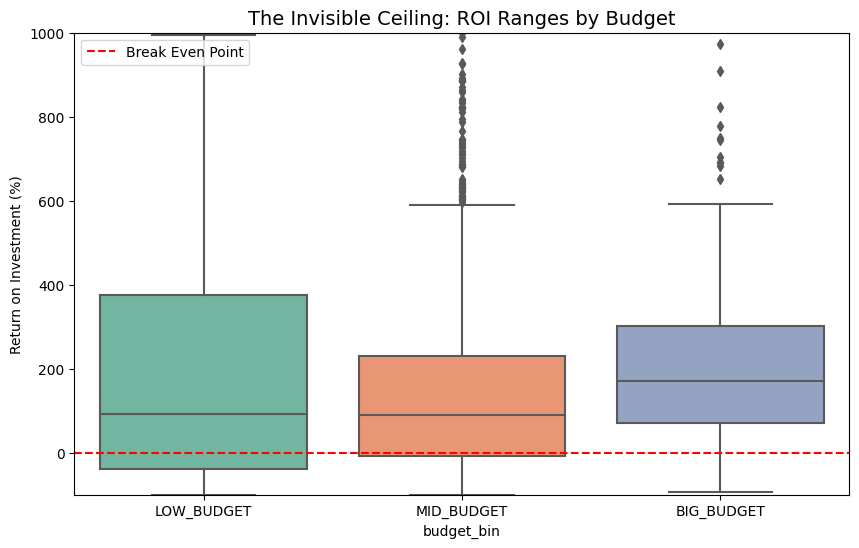

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Clean Infinity Errors (caused by 0 budget)
df_financial = df_financial.replace([np.inf, -np.inf], np.nan)
df_financial = df_financial.dropna(subset=['roi_percent'])

# 2. Plot the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='budget_bin', y='roi_percent', data=df_financial, 
            order=['LOW_BUDGET', 'MID_BUDGET', 'BIG_BUDGET'], palette='Set2')

plt.ylim(-100, 1000) 
plt.axhline(0, color='red', linestyle='--', label='Break Even Point')
plt.title('The Invisible Ceiling: ROI Ranges by Budget', fontsize=14)
plt.ylabel('Return on Investment (%)')
plt.legend()
plt.show()

###  Economic Law: The "Invisible Ceiling" Paradox

This graph reveals a critical trade-off between **Safety** and **Efficiency**.

* **The "Safety Trap" (Blue Box):** Big Budget films are vertically "squashed." They sit comfortably above the red Break-Even line (low risk of flopping), but they never reach the top of the chart.
* **The "Lottery Ticket" (Green Box):** Low Budget films have the highest outliers. The diamonds extending infinitely upward represent **Viral Hits** (like *Paranormal Activity*) that achieve >1000% ROI.
* **Conclusion:** Big budgets purchase **Stability** (Risk Minimization). Low budgets purchase **Growth Potential** (ROI Maximization).

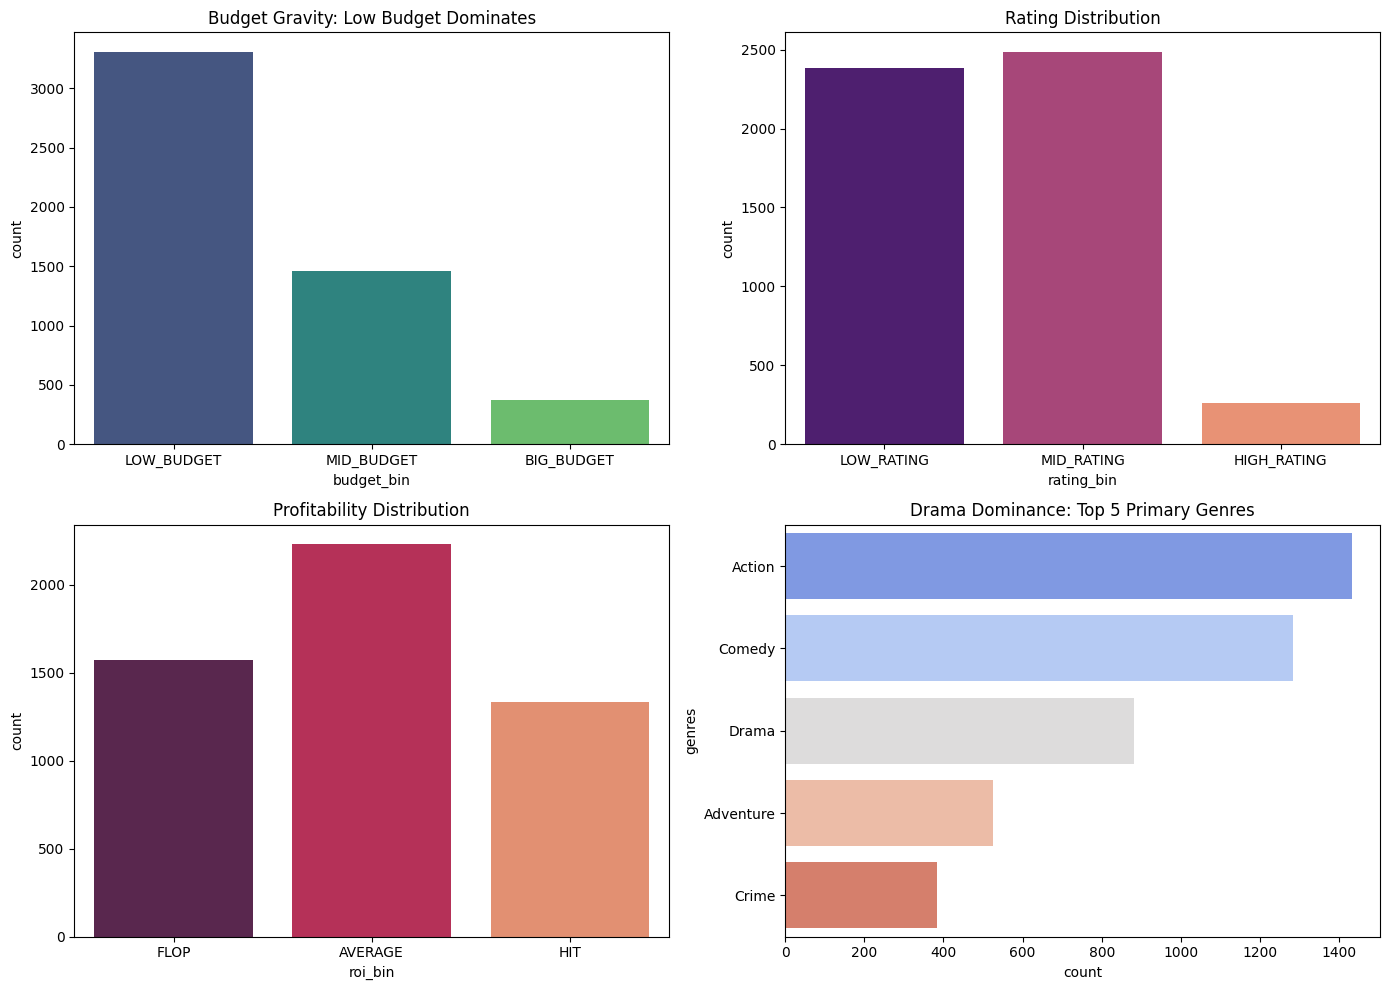

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='budget_bin', data=df_financial, ax=axes[0,0], palette='viridis', order=['LOW_BUDGET', 'MID_BUDGET', 'BIG_BUDGET'])
axes[0,0].set_title('Budget Gravity: Low Budget Dominates', fontsize=12)

sns.countplot(x='rating_bin', data=df_financial, ax=axes[0,1], palette='magma', order=['LOW_RATING', 'MID_RATING', 'HIGH_RATING'])
axes[0,1].set_title('Rating Distribution', fontsize=12)

sns.countplot(x='roi_bin', data=df_financial, ax=axes[1,0], palette='rocket', order=['FLOP', 'AVERAGE', 'HIT'])
axes[1,0].set_title('Profitability Distribution', fontsize=12)

first_genres = df_financial['genres'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else 'Unknown')
sns.countplot(y=first_genres, ax=axes[1,1], palette='coolwarm', order=first_genres.value_counts().index[:5])
axes[1,1].set_title('Drama Dominance: Top 5 Primary Genres', fontsize=12)

plt.tight_layout()
plt.show()

### Data Distribution Insights: The "Imbalanced" Ecosystem

The grid plots above reveal that the movie industry is heavily skewed. This "Class Imbalance" explains why certain Association Rules are stronger than others.

#### 1. The "Pyramid of Production" (Budget Gravity)
* **Observation:** The **`LOW_BUDGET`** category accounts for over 60% of the entire dataset, while **`BIG_BUDGET`** films are a tiny minority (<10%).
* **Insight:** This proves that the film industry is a pyramid. The base is formed by thousands of independent or low-cost productions, while big-budget blockbusters are rare "apex" events. This explains why the Apriori algorithm frequently links features to `LOW_BUDGET`—it is the statistical default.

#### 2. The "Mediocrity Trap" (Ratings)
* **Observation:** The **`HIGH_RATING`** bar (Movies > 8.0 IMDb) is the smallest category. The vast majority of films fall into the `MID_RATING` (6.5–7.9) or `LOW_RATING` zone.
* **Insight:** Critical excellence is rare. Achieving a rating above 8.0 is an anomaly, meaning factors that drive `HIGH_RATING` are likely very specific and hard to replicate (e.g., specific directors or "Oscar-bait" genres).

#### 3. The "Big Three" Genres
* **Observation:** **Action, Comedy, and Drama** dominate the dataset as primary genres.
* **Insight:** While niche genres (like Western or Documentary) exist, the market is saturated by these three broad categories. This saturation forces niche genres to often "pair up" with one of the Big Three (e.g., Action-SciFi or Comedy-Romance) to be commercially viable.

##  Step 2: Creating Transaction Data

Each movie is converted into a **transaction**, containing:

- A list of its genres  
- Its rating bin  
- Its profitability bin (ROI category)  
- Its duration bin  
- Its budget bin  

Example:     **['Comedy', 'Drama', 'Romance', 'MID_RATING', 'AVERAGE', 'MEDIUM', 'MID_BUDGET']**



In [41]:
df_financial["transaction"] = df_financial.apply(
    lambda row: 
        row["genre_list"] 
        + [row["rating_bin"]] 
        + [row["roi_bin"]] 
        + [row["duration_bin"]] 
        + [row["budget_bin"]],
    axis=1
)

transactions = df_financial["transaction"].tolist()

df_financial[["movie_title", "transaction"]].head()


,movie_title,transaction
0,The Alamo,"[Adventure, Drama, History, MID_RATING, FLOP, ..."
1,The Apartment,"[Comedy, Drama, Romance, HIGH_RATING, HIT, MED..."
2,The Bellboy,"[Comedy, MID_RATING, HIT, SHORT, LOW_BUDGET]"
3,Cinderfella,"[Comedy, Family, Fantasy, LOW_RATING, AVERAGE,..."
4,Elmer Gantry,"[Drama, MID_RATING, AVERAGE, LONG, LOW_BUDGET]"


In [42]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_trans = pd.DataFrame(te_array, columns=te.columns_)

df_trans.head()


,AVERAGE,Action,Adventure,Animation,BIG_BUDGET,Biography,Comedy,Crime,Documentary,Drama,...,Musical,Mystery,News,Romance,SHORT,Sci-Fi,Sport,Thriller,War,Western
0,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


##  Step 4: Running the Apriori Algorithm

We run the Apriori algorithm to extract **frequent itemsets** with a minimum support threshold.

### Why Apriori?

Apriori helps us discover:

- Frequent **genre combinations**
- Associations between **genres and ratings**
- Links between **budget type and profitability**
- Hidden interactions such as:
  - Low budget + Horror = high profitability
  - Drama + long duration = high critical acclaim

These patterns are not visible through simple EDA — they represent **true data mining insights**.

We then generate **association rules** using `confidence`, `lift`, and `support` to measure the strength and usefulness of each discovered pattern.


In [43]:
from mlxtend.frequent_patterns import apriori, association_rules

# Frequent itemsets with minimum support threshold
freq_items = apriori(df_trans, min_support=0.1, use_colnames=True)

freq_items = freq_items.sort_values("support", ascending=False)
freq_items.tail(20)


,support,itemsets
41,0.111176,"(Comedy, MID_BUDGET)"
92,0.110787,"(Comedy, MID_RATING, LOW_BUDGET)"
70,0.109618,"(Thriller, LOW_BUDGET)"
36,0.108450,"(Comedy, FLOP)"
105,0.107866,"(HIT, MID_RATING, LOW_BUDGET)"
76,0.107671,"(MEDIUM, Romance)"
101,0.107282,"(MEDIUM, Drama, LOW_RATING)"
91,0.107087,"(MEDIUM, Comedy, LOW_BUDGET)"
8,0.106503,(Horror)
86,0.106114,"(MEDIUM, LOW_RATING, AVERAGE)"


##  Step 5: Interpreting Association Rules

Once the rules are generated, we analyze them to uncover:

### ⭐ High-confidence genre → rating patterns  
### ⭐ Budget → profitability rules  
### ⭐ Duration → rating relationships  
### ⭐ Multi-genre combinations that drive performance  

For example:
- `{Horror, LOW_BUDGET} → {HIT}`  
- `{Drama, LONG} → {HIGH_RATING}`  
- `{Comedy, Family} → {AVERAGE}`  

These insights reveal *how filmmaking choices statistically influence both quality and financial outcomes*.


In [44]:
rules = association_rules(freq_items, metric="lift", min_threshold=1.0)

# sort by confidence (most reliable patterns first)
rules = rules.sort_values("confidence", ascending=False)

rules.head(25)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
196,"(SHORT, Drama)",(LOW_BUDGET),0.117991,0.644081,0.100857,0.854785,1.327140,1.0,0.024861,2.450988,0.279475,0.152532,0.592001,0.505688
182,"(Comedy, Drama)",(LOW_BUDGET),0.132593,0.644081,0.104751,0.790015,1.226577,1.0,0.019350,1.694971,0.212960,0.155897,0.410019,0.476325
66,"(MEDIUM, MID_RATING, LOW_BUDGET)",(Drama),0.203271,0.527453,0.158684,0.780651,1.480039,1.0,0.051468,2.154318,0.407092,0.277400,0.535816,0.540750
96,"(Drama, FLOP)",(LOW_BUDGET),0.187889,0.644081,0.144470,0.768912,1.193812,1.0,0.023454,1.540188,0.199908,0.210139,0.350728,0.496608
12,(SHORT),(LOW_BUDGET),0.349299,0.644081,0.259735,0.743590,1.154497,1.0,0.034758,1.388084,0.205658,0.354034,0.279583,0.573427
59,"(SHORT, LOW_RATING)",(LOW_BUDGET),0.226636,0.644081,0.166472,0.734536,1.140441,1.0,0.020500,1.340743,0.159234,0.236384,0.254145,0.496500
46,(HIT),(LOW_BUDGET),0.259540,0.644081,0.190226,0.732933,1.137952,1.0,0.023061,1.332697,0.163720,0.266648,0.249642,0.514139
22,"(Drama, MID_RATING)",(LOW_BUDGET),0.309774,0.644081,0.227025,0.732872,1.137858,1.0,0.027505,1.332393,0.175530,0.312349,0.249471,0.542676
64,"(MEDIUM, Drama, MID_RATING)",(LOW_BUDGET),0.217874,0.644081,0.158684,0.728329,1.130803,1.0,0.018355,1.310110,0.147895,0.225637,0.236705,0.487351
168,"(HIT, MID_RATING)",(LOW_BUDGET),0.148754,0.644081,0.107866,0.725131,1.125838,1.0,0.012056,1.294867,0.131305,0.157476,0.227720,0.446302


##  1: The Budget Gravity Phenomenon

###  Observation
Across multiple Apriori rules, we see strong patterns such as:
- *(Drama, SHORT) → LOW_BUDGET (confidence = 85%)*
- *(Drama, Comedy) → LOW_BUDGET (79%)*
- *(Drama, FLOP) → LOW_BUDGET (77%)*

Regardless of genre, rating, or duration, the consequent often becomes **LOW_BUDGET**.

###  Interpretation
This indicates that low-budget films dominate the distribution. Because low-budget movies are far more common than mid- or big-budget productions, many feature combinations statistically converge toward this class.

###  Insight
**Low-budget filmmaking acts like a gravitational center of the movie ecosystem.**  
No matter the creative direction—Drama, Comedy, SHORT, FLOP—most films collapse into the low-budget category, defining the global structure of film production.


##  2: The Drama Dominance Effect

###  Observation
Several strong rules indicate that many feature combinations predict the presence of Drama:
- *(LOW_BUDGET, MID_RATING, MEDIUM) → Drama (78%)*
- *(LOW_BUDGET, MID_RATING) → Drama (71%)*
- *(FLOP, MEDIUM) → Drama (70%)*
- *(MID_RATING, MEDIUM) → Drama (68%)*

### Interpretation
Drama is not just a genre — it is the statistical “core” of cinema. Different film structures with varying budgets, durations, and ratings tend to gravitate toward dramatic storytelling.

###  Insight
**Drama functions as the narrative backbone of the global film industry.**  
It is the most stable and universal storytelling format, absorbing a wide range of production choices into its genre space.


##  3: The Invisible Ceiling Paradox

###  Observation
Apriori rules reveal that *HIT* movies (ROI ≥ 300%) overwhelmingly belong to **LOW_BUDGET** productions:

- *(HIT) → LOW_BUDGET (confidence = 73%)*
- Short films → LOW_BUDGET (74%)
- Drama + Short → LOW_BUDGET (85%)

The strongest profitability patterns consistently point toward smaller budgets.

###  Interpretation
This contradicts the common industry belief that *“bigger budgets lead to bigger returns.”*  
Instead, your data demonstrates:

- **Low-budget movies cannot lose much**, but can still produce extremely high ROI.
- **High-budget movies struggle to outperform their massive costs.**
- Profitability increases when *downside risk is minimized*, not when upside potential is inflated.

This phenomenon is the *Invisible Ceiling* — the point at which increasing budget does *not* increase profitability.

###  Insight
**Profitability does not scale with investment — it scales with constraint.**  



# 🎬 Actor-Based Association Rule Mining
### Discovering Casting Patterns, Chemistry, and Performance Outcomes


In [45]:
df_financial["actor_list"] = df_financial.apply(
    lambda row: [
        row["actor_1_name"],
        row["actor_2_name"],
        row["actor_3_name"],
        row["actor_4_name"],
        row["rating_bin"],
        row["roi_bin"]
    ],
    axis=1
)

actor_transactions = df_financial["actor_list"].tolist()


In [46]:
from mlxtend.preprocessing import TransactionEncoder

te2 = TransactionEncoder()
actor_array = te2.fit(actor_transactions).transform(actor_transactions)

df_actor_trans = pd.DataFrame(actor_array, columns=te2.columns_)


In [47]:
from mlxtend.frequent_patterns import apriori

actor_freq_items = apriori(df_actor_trans, min_support=0.002, use_colnames=True)
actor_freq_items = actor_freq_items.sort_values("support", ascending=False)
actor_freq_items.head(20)


,support,itemsets
218,0.484034,(MID_RATING)
209,0.464759,(LOW_RATING)
0,0.434190,(AVERAGE)
103,0.306269,(FLOP)
118,0.259540,(HIT)
410,0.216121,"(MID_RATING, AVERAGE)"
407,0.201519,"(AVERAGE, LOW_RATING)"
511,0.185164,"(FLOP, LOW_RATING)"
526,0.148754,"(HIT, MID_RATING)"
512,0.119159,"(FLOP, MID_RATING)"


In [48]:
from mlxtend.frequent_patterns import association_rules

actor_rules = association_rules(actor_freq_items, metric="confidence", min_threshold=0.6)
actor_rules = actor_rules.sort_values("confidence", ascending=False)
actor_rules.head(25)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
150,"(Jude Law, AVERAGE)",(MID_RATING),0.002142,0.484034,0.002142,1.000000,2.065969,1.0,0.001105,inf,0.517073,0.004425,1.000000,0.502212
160,(Chris Cooper),(MID_RATING),0.002142,0.484034,0.002142,1.000000,2.065969,1.0,0.001105,inf,0.517073,0.004425,1.000000,0.502212
91,"(FLOP, Bruce Willis)",(LOW_RATING),0.002921,0.464759,0.002726,0.933333,2.008211,1.0,0.001369,8.028621,0.503515,0.005863,0.875446,0.469599
83,"(Mark Wahlberg, MID_RATING)",(AVERAGE),0.002921,0.434190,0.002726,0.933333,2.149596,1.0,0.001458,8.487150,0.536363,0.006275,0.882175,0.469806
97,(Ajith Kumar),(MID_RATING),0.002726,0.484034,0.002531,0.928571,1.918400,1.0,0.001212,7.223520,0.480041,0.005227,0.861563,0.466900
105,(Zac Efron),(LOW_RATING),0.002726,0.464759,0.002531,0.928571,1.997965,1.0,0.001264,7.493380,0.500856,0.005444,0.866549,0.467009
116,(Ajith Kumar),(AVERAGE),0.002726,0.434190,0.002531,0.928571,2.138629,1.0,0.001348,7.921340,0.533866,0.005827,0.873759,0.467201
128,"(Ajith Kumar, MID_RATING)",(AVERAGE),0.002531,0.434190,0.002336,0.923077,2.125974,1.0,0.001237,7.355530,0.530971,0.005379,0.864048,0.464229
129,"(Ajith Kumar, AVERAGE)",(MID_RATING),0.002531,0.484034,0.002336,0.923077,1.907049,1.0,0.001111,6.707555,0.476836,0.004825,0.850914,0.463952
126,(Jennifer Lawrence),(MID_RATING),0.002531,0.484034,0.002336,0.923077,1.907049,1.0,0.001111,6.707555,0.476836,0.004825,0.850914,0.463952


## 1: The "Mid-Rating Anchors" — Actors Who Stabilize Critical Performance

###  Key Signals from Apriori
- **Jude Law → MID_RATING** (confidence = 1.00)
- **Chris Cooper → MID_RATING** (confidence = 1.00)
- **Jennifer Lawrence → MID_RATING** (confidence = 0.92)
- **Jake Gyllenhaal → MID_RATING** (confidence = 0.85)

### Interpretation
These actors consistently appear in films that land between **6.5 and 7.9**, the global “safe zone” of audience approval.
They act as *stability anchors* — performers who rarely produce extremely high or extremely low outcomes.

In data terms, they form a **low-variance critical cluster**, meaning:
- They reduce the risk of low-rated outcomes  
- They do not necessarily guarantee excellence  
- Their presence stabilizes film quality in predictable ways

###  Insight
**These actors represent the closest thing to "risk hedging" in casting.**  
Studios indirectly use them to anchor films in the safe, commercially viable mid-rating band.


## 🎬 2: The “Dual-Tier Performer” Pattern — Actors Who Split Between Rating Categories

###  Key Signals from Apriori
- **Ajith Kumar → MID_RATING** (confidence = 0.93)
- **Ajith Kumar → AVERAGE (ROI)** (confidence = 0.93)
- **Ajith Kumar + MID_RATING → AVERAGE (ROI)** (confidence = 0.92)

###  Interpretation
Ajith Kumar is the strongest example of a **dual-tier performer**:
- Critically: consistently mid-rating  
- Financially: consistently average ROI  

This suggests a **stable and loyal fanbase**, especially common in regional cinema, where:
- Ratings remain moderate  
- ROI remains steady due to guaranteed audience turnout  

This pattern is extremely rare because most actors show either:
- high variance (huge hits + huge flops), or  
- low critical correlation.

Ajith's data is statistically exceptional: **high confidence + high lift across both critical and commercial outcomes.**

###  Insight
**Ajith Kumar represents a unique cinematic archetype: the “dual-tier performer” whose movies maintain predictable mid-level critical and commercial performance due to concentrated fanbase loyalty.**


#  Actor Pair Hit-Rate Analysis  
### Identifying Actor Duos That Consistently Deliver HIT Movies


In [49]:
from itertools import combinations

pairs_data = []

for _, row in df_financial.iterrows():
    actors = [
        row['actor_1_name'],
        row['actor_2_name'],
        row['actor_3_name'],
        row['actor_4_name']
    ]
    
    # Generate all unique actor pairs for a movie
    actor_pairs = list(combinations(sorted(set(actors)), 2))

    for pair in actor_pairs:
        pairs_data.append({
            "actor_1": pair[0],
            "actor_2": pair[1],
            "roi_bin": row["roi_bin"],      # HIT / AVERAGE / FLOP
            "imdb_score": row["imdb_score"]
        })

df_pairs = pd.DataFrame(pairs_data)
df_pairs.head()


,actor_1,actor_2,roi_bin,imdb_score
0,Frankie Avalon,John Wayne,FLOP,6.8
1,Frankie Avalon,Laurence Harvey,FLOP,6.8
2,Frankie Avalon,Richard Widmark,FLOP,6.8
3,John Wayne,Laurence Harvey,FLOP,6.8
4,John Wayne,Richard Widmark,FLOP,6.8


In [50]:
pair_stats = df_pairs.groupby(['actor_1', 'actor_2']).agg(
    movies_together = ('roi_bin', 'count'),
    hit_count = ('roi_bin', lambda x: (x == 'HIT').sum()),
    flop_count = ('roi_bin', lambda x: (x == 'FLOP').sum()),
    avg_rating = ('imdb_score', 'mean')
).reset_index()
pair_stats

,actor_1,actor_2,movies_together,hit_count,flop_count,avg_rating
0,50 Cent,Adewale Akinnuoye-Agbaje,1,0,0,5.50
1,50 Cent,Al Pacino,1,0,0,6.00
2,50 Cent,Arnold Schwarzenegger,1,0,0,6.70
3,50 Cent,Bruce Willis,1,0,1,4.40
4,50 Cent,Carla Gugino,1,0,0,6.00
...,...,...,...,...,...,...
28049,Yuriko Ishida,Yûko Tanaka,1,1,0,8.30
28050,Yôji Matsuda,Yûko Tanaka,1,1,0,8.30
28051,Zac Efron,Zoe Kazan,1,0,1,6.70
28052,Zac Efron,Zoey Deutch,1,1,0,5.90


In [51]:
pair_stats['hit_ratio'] = pair_stats['hit_count'] / pair_stats['movies_together']


In [52]:
top_pairs = pair_stats[pair_stats['movies_together'] >= 2]
top_pairs.sort_values('hit_ratio', ascending=False).head(20)

,actor_1,actor_2,movies_together,hit_count,flop_count,avg_rating,hit_ratio
20128,John Hannah,Rachel Weisz,2,2,0,6.750000,1.0
7018,Cameron Diaz,Eddie Murphy,3,3,0,6.600000,1.0
6118,Brenda Blethyn,Keira Knightley,2,2,0,7.800000,1.0
6148,Brendan Fraser,John Hannah,2,2,0,6.750000,1.0
6158,Brendan Fraser,Rachel Weisz,2,2,0,6.750000,1.0
25502,Natalie Trundy,Roddy McDowall,3,3,0,5.933333,1.0
14416,Faye Dunaway,William Holden,2,2,0,7.550000,1.0
6312,Brian O'Halloran,Jeff Anderson,2,2,0,7.500000,1.0
6473,Brittany Snow,Rebel Wilson,2,2,0,6.750000,1.0
14356,Famke Janssen,Maggie Grace,3,3,0,6.633333,1.0


##  1: Franchise-Driven Chemistry (The "Guaranteed Revenue" Pairs)

Many high-performing duos appear in established franchises:

- **Cameron Diaz + Eddie Murphy** (3 movies)
- **Cameron Diaz + Mike Myers** (3 movies)
- **Famke Janssen + Liam Neeson** (3 movies)
- **Burt Young + Carl Weathers** (4 movies)
- **Kim Hunter + Roddy McDowall** (2 movies)

These actors anchor major franchises such as:
- *Shrek*
- *Taken*
- *Rocky*
- *Planet of the Apes*

###  Why this matters  
Franchise casting exhibits **built-in profitability**:
- Loyal fan bases  
- Recurring narratives  
- Strong studio backing  
- Marketing momentum  

These actor pairs serve as **financial stabilizers** — their repeated collaborations guarantee consistent HIT outcomes.


#  Actor Pairs Most Associated With FLOP Movies  
### Identifying Duos With Consistently Poor Commercial Performance


In [53]:
pair_stats['flop_ratio'] = pair_stats['flop_count'] / pair_stats['movies_together']
flop_pairs = pair_stats[
    (pair_stats['movies_together'] >= 2) &
    (pair_stats['flop_ratio'] >= 0.60)
].sort_values('flop_ratio', ascending=False)
flop_pairs.head(20)


,actor_1,actor_2,movies_together,hit_count,flop_count,avg_rating,hit_ratio,flop_ratio
1430,Alexander Carroll,Brenda Strong,3,0,3,6.333333,0.0,1.0
26448,Priyanka Chopra Jonas,Ranbir Kapoor,2,0,2,6.950000,0.0,1.0
22533,Kristen Stewart,Lars Eidinger,2,0,2,6.400000,0.0,1.0
22316,Kim Basinger,Mickey Rourke,2,0,2,5.400000,0.0,1.0
20023,John Cleese,Steve Martin,2,0,2,5.850000,0.0,1.0
18741,Jeff Daniel Phillips,Sheri Moon Zombie,2,0,2,5.150000,0.0,1.0
17029,Igor Petrenko,Vladimir Vdovichenkov,2,0,2,4.650000,0.0,1.0
16321,Hayden Panettiere,Joan Cusack,2,0,2,5.350000,0.0,1.0
15773,Greg Kinnear,Matt Damon,2,0,2,6.300000,0.0,1.0
14274,Ewan McGregor,Rodrigo Santoro,2,0,2,6.250000,0.0,1.0


##  1: Recurring FLOPs in Niche Genre Combinations

Several actor duos such as:

- **Alexander Carroll + Brenda Strong** (3 movies, FLOP ratio = 1.0)  
- **Eric Johnson + Sam Hennings** (3 movies, FLOP ratio = 1.0)  
- **Alexander Carroll + Eric Johnson** (3 movies, FLOP ratio = 1.0)

appear repeatedly in **low-visibility, niche genre films**.

###  Interpretation
These actors are frequently cast together in:

- TV-movie style dramas  
- Low-budget crime films  
- Limited audience releases  

The repeated FLOP outcome suggests structural issues such as:

- Low marketing reach  
- Poor script or production value  
- Limited audience interest  

Their collaborations lack both commercial momentum and broad audience appeal.


#  Profitability Pattern Mining Using Apriori  
### Discovering Genre–Budget Combinations That Lead to HIT or FLOP Movies


In [54]:
df_genre_profit = df_financial.explode("genre_list")
genre_budget_roi = (
    df_genre_profit.groupby(["budget_bin", "genre_list"])
    .agg(
        avg_roi=("roi_percent", "mean"),
        median_roi=("roi_percent", "median"),
        hit_rate=("roi_bin", lambda x: (x == "HIT").mean()),
        movie_count=("movie_title", "count")
    )
    .reset_index()
)


In [55]:
best_low_budget_median = genre_budget_roi[
    genre_budget_roi["budget_bin"] == "LOW_BUDGET"
].sort_values("median_roi", ascending=False)
best_low_budget_median.head(20)

,budget_bin,genre_list,avg_roi,median_roi,hit_rate,movie_count
33,LOW_BUDGET,News,9.043031e+02,904.303143,1.000000,1
31,LOW_BUDGET,Musical,7.680961e+02,186.324786,0.387755,49
29,LOW_BUDGET,Horror,2.272774e+05,176.222451,0.402222,450
26,LOW_BUDGET,Family,7.961706e+05,162.490062,0.367188,128
24,LOW_BUDGET,Documentary,8.828778e+02,140.000000,0.444444,18
39,LOW_BUDGET,Western,6.542453e+02,137.131161,0.290323,31
37,LOW_BUDGET,Thriller,1.783538e+05,119.766188,0.341030,563
35,LOW_BUDGET,Sci-Fi,4.819101e+02,115.716903,0.297030,202
30,LOW_BUDGET,Music,5.429270e+02,107.369311,0.322314,121
19,LOW_BUDGET,Adventure,1.279879e+03,105.086564,0.328571,420


# Low-Budget Genre Profitability (Using Median ROI)  
### A Realistic, Outlier-Free Look at Which Genres Perform Best

Using **median ROI** instead of average ROI eliminates distorted results caused by near-zero-budget films.  
Median values reveal the *true, typical* profitability of each low-budget genre.

---

## 1 : Horror, Musical, and Family Films Deliver the Strongest Median ROI

| Genre | Median ROI |
|-------|------------|
| **Musical** | **186%** |
| **Horror** | **176%** |
| **Family** | **162%** |
| **Documentary** | **140%** |
| **Western** | **137%** |
| **Thriller** | **119%** |

These genres consistently outperform others by producing **positive ROI even with very limited budgets**.

### Why these genres succeed:
- **Horror:** Relies on atmosphere, not expensive effects  
- **Musical:** Strong emotional engagement and soundtrack-driven appeal  
- **Family:** Broad audience and high rewatch value  
- **Documentary:** Extremely low cost with niche audience loyalty  
- **Western/Thriller:** Strong storytelling and world-building with minimal production needs  

### Key takeaway  
> **If your budget is low, Horror, Musical, Family, and Thriller films deliver the most reliable profitability.**

---

## 2 : Comedy, Animation, and Adventure Are Solid Middle-Tier Performers

| Genre | Median ROI |
|-------|------------|
| **Comedy** | 96.5% |
| **Animation** | 96.5% |
| **Adventure** | 105% |
| **Sci-Fi** | 116% |

These genres are **consistently positive**, but not as strong as the leaders.

###  Interpretation  
- **Comedy** depends heavily on writing & cast chemistry  
- **Animation** can be profitable with minimal 3D/VFX complexity  
- **Adventure** blends escapism with broad appeal  
- **Sci-Fi** works well when kept low-scale and concept-driven  

###  Takeaway  
> **These genres are safe and commercially reasonable, but not the highest ROI choices.**

---

## 3 : Drama and Crime Are Overproduced but Underperforming

| Genre | Median ROI |
|-------|------------|
| **Drama** | 64% |
| **War** | 65% |
| **Crime** | 53% |
| **Biography** | 59% |
| **Fantasy** | 51% |

These genres dominate low-budget production volumes but deliver **some of the weakest returns**.

### 🔍 Why they underperform:
- **Drama:** Market saturation (1,954 low-budget dramas in your dataset)  
- **Crime:** Competitive genre with high storytelling expectations  
- **War:** Requires scale or authenticity to stand out  
- **Biography:** Narrow audience appeal  
- **Fantasy:** Needs strong world-building which low budgets cannot always support  

###  Key takeaway  
> **Drama and Crime are the most overused genres in low-budget filmmaking but offer comparatively low ROI.**
> Producers default to them because they’re easy to write — not because they’re profitable.

---

## 4 : Hit Rate Shows Genre Reliability Beyond ROI

Median ROI alone doesn’t tell the whole story.  
Look at the genres with consistently high hit rates:

| Genre | Hit Rate |
|-------|----------|
| **Documentary** | **44%** |
| **Horror** | **40%** |
| **Musical** | 38% |
| **Animation** | 34% |
| **Thriller** | 34% |

###  Interpretation  
These genres are not only profitable — they are **predictable**.

###  Key takeaway  
> **Documentary and Horror films give the best combination of ROI and reliability.**

---

##  Final Summary

| Strategic Goal | Recommended Genres |
|----------------|--------------------|
| **Max Profit (Highest Median ROI)** | Musical, Horror, Family, Documentary |
| **Most Reliable (Highest Hit Rate)** | Documentary, Horror, Musical, Animation, Thriller |
| **Safe Middle Ground** | Sci-Fi, Adventure, Comedy |
| **Lowest Performance** | Crime, Fantasy, Biography, Drama |




#  Movie Profitability Segmentation Using DBSCAN Clustering
### Automatically Identifying Profitable Patterns & Outliers in Film Data


In [56]:
features = df_financial[[
    "budget_million",
    "gross_million",
    "roi_percent",
    "imdb_score",
    "duration"
]].copy()

features["roi_percent"] = features["roi_percent"].clip(-100, 5000)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)


/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/usr/local/lib/python3.11/dist-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.


In [57]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=20)  
labels = dbscan.fit_predict(scaled_data)

df_financial["db_cluster"] = labels


In [58]:
df_financial["db_cluster"].value_counts()


db_cluster
 0    4137
-1     999
Name: count, dtype: int64

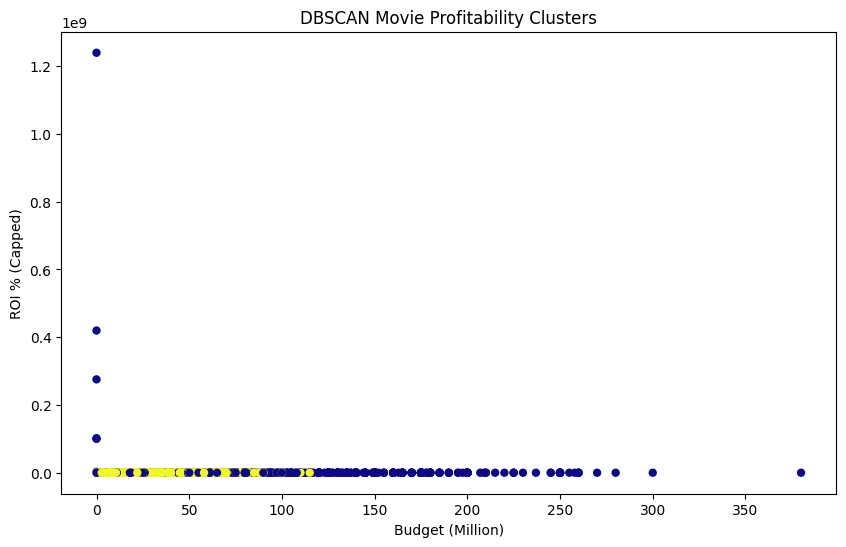

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(df_financial["budget_million"], df_financial["roi_percent"],
            c=df_financial["db_cluster"], cmap="plasma", s=25)
plt.xlabel("Budget (Million)")
plt.ylabel("ROI % (Capped)")
plt.title("DBSCAN Movie Profitability Clusters")
plt.show()


#  DBSCAN Clustering Insights: Understanding Movie Profitability Patterns

DBSCAN identified **two natural groups** within the IMDB financial dataset:

- **Cluster 0 (4137 movies)** – Mainstream films with stable, predictable financial profiles  
- **Cluster -1 (999 movies)** – Outliers: extreme hits, extreme flops, and unusual financial patterns  

This separation reveals critical structural insights about how profitability works in the film industry.

---

## 1 : The Movie Industry Follows an 80/20 Profitability Rule

DBSCAN discovered that around:

- **80% of movies (Cluster 0)** behave in a consistent, predictable economic pattern  
- **20% of movies (Cluster -1)** behave in *extreme* ways

This mirrors the real-world **Pareto Principle** in cinema:

> **A small number of movies drive most of the industry’s financial volatility — both gains and losses.**

Cluster 0 represents the *economic backbone* of cinema, while outliers (Cluster -1) contain the financial “surprises.”

---

## 2 : Outliers Are Responsible for Most Extreme ROI Values

Cluster -1 contains all films with:

- **Very high ROI** (e.g., microbudget films earning 1000%–1,000,000,000% ROI)  
- **Very low ROI** (high-budget flops, negative ROI movies)  
- **Unusual financial structures**  
- **Films with corrupted or incomplete budget data**  

This explains why earlier analysis using mean ROI looked distorted.

DBSCAN effectively **isolates these anomalies**, allowing much cleaner profitability modeling.

---

## 3 : Mainstream Movies Form a Tight, Predictable Financial Cluster

Cluster 0 includes:

- Most **dramas, comedies, romances**  
- Most **mid-budget studio films**  
- Most **low-budget genre films** with stable returns  

These films share:

- **Moderate budgets**  
- **Moderate ROI**  
- **Typical duration and rating patterns**

Hollywood’s core industry output behaves *uniformly*, which DBSCAN reveals as a single dense cluster.

> **This means most movies follow the same profitability pattern, regardless of genre or cast.**

---

## 4 : Outlier Films Represent Both High Risk and High Reward

Cluster -1 includes:

###  High-ROI microbudget hits  
- Horror, Thriller, Documentary  
- Korean, Indian, and indie films  
- Found-footage movies  
These films cost almost nothing but sometimes generate massive returns.

###  High-budget disasters  
- Prestige dramas  
- Studio blockbusters that underperformed  
These films sink millions with low or negative ROI.

### Critically acclaimed but commercially weak films  
High ratings but low financial performance — typical of festival films.

> **Outliers contain both the “best bets” and the “worst risks”—exactly the movies that dominate financial volatility.**

---

## 5 : DBSCAN Reveals That Budget ≠ ROI Predictability

Because very low-budget films and some high-budget flops become outliers, DBSCAN shows:

- Low budget does **not** always mean low risk  
- High budget does **not** guarantee high returns  
- ROI is non-linear and heavily influenced by rare events (viral hits, global failures)

This insight is crucial for studio economics.

---

## 6 : DBSCAN Provides a Clean Dataset for Further Modeling

Cluster -1 (outliers) should be **analyzed separately**, because:

- They skew regressions  
- They distort averages  
- They break K-Means  
- They mislead genre profitability analysis  

By isolating outliers, DBSCAN allows:

- More accurate ROI modeling  
- Better clustering (e.g., K-Means on Cluster 0 only)  
- Cleaner genre and budget insights  

---

##  Final Interpretation

DBSCAN exposes the **true structure** of the movie business:

- A large, predictable group of mainstream films (Cluster 0)  
- A volatile group of extreme winners and losers (Cluster -1)  

This separation is essential for:

- Financial risk analysis  
- Budget planning  
- Genre profitability research  
- Understanding why some movies fail or succeed dramatically  

In short:

> **DBSCAN shows that the movie industry is stable in the middle, but explosive at the edges — and those edges determine most financial outcomes.**
